In [ ]:
##i want to look at what between sample variants are being shared between who
## so i'm going to read in my shared between sample variants dfs, and look at which are shared between
##chickens adn ducks, or across outbreaks (defined by sampling date)
## and maybe some other stuff....

In [38]:
import pandas as pd
import numpy as np

In [39]:
# df = pd.read_csv('../../seq/analysis/output_dfs/2026-02-26_shared_vars_between_samples_geneposAA-allcom.tsv', sep='\t')
# df = pd.read_csv('../../seq/analysis/output_dfs/2026_04_08_repshared_SNVs_allcom_lbm_2pct.tsv', sep='\t')
df = pd.read_csv('../output_dfs/2026-05-21_repshared_SNVs_allcom_lbm_2pct.tsv', sep='\t')

df

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,order,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype
0,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1
1,na,67,T,Val16Ala,NaN,0.2439,0.2890,c_com5,16,NA_16,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1
2,na,76,T,Ile19Thr,NaN,0.2454,0.2615,c_com5,19,NA_19,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1
3,na,79,T,Ile20Thr,NaN,0.2392,0.2624,c_com5,20,NA_20,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935,anseriformes_commercial,PB2_1560,B3.3
303,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800,anseriformes_commercial,PB2_1659,B3.3
304,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,NP_1023,B3.3
305,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,PB2_1659,B3.3


In [4]:
df.columns

Index(['segment', 'position', 'allele', 'coding_region_change', 'gene',
       'Frequency_1', 'Frequency_2', 'sample', 'amino_acid', 'gene_pos',
       'sample_var', 'syn_non', 'sample_ID', 'domestic_status', 'ct_value',
       'rep_shared', 'order', 'county', 'date', 'species', 'species_group',
       'color', 'avg_freq', 'order_domstat', 'gene_pos_nt', 'genotype'],
      dtype='object')

In [40]:
df_small = df[['coding_region_change', 'sample_ID', 'gene_pos', 'syn_non', 'domestic_status']]
df_small

,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status
0,Ile8Thr,c_com5,NA_8,nonsynonymous,commercial
1,Val16Ala,c_com5,NA_16,nonsynonymous,commercial
2,Ile19Thr,c_com5,NA_19,nonsynonymous,commercial
3,Ile20Thr,c_com5,NA_20,nonsynonymous,commercial
4,Asp383Asp,c_com5,PA_383,synonymous,commercial
...,...,...,...,...,...
302,Val511Val,kc_com6,PB2_511,synonymous,commercial
303,Ser544Ser,kc_com6,PB2_544,synonymous,commercial
304,Ser326Ser,kc_com7,NP_326,synonymous,commercial
305,Ser544Ser,kc_com7,PB2_544,synonymous,commercial


In [41]:
meta= pd.read_csv('../sample_data/PA_samples_seqd_throughrun10.tsv', sep='\t')
meta.columns

Index(['sample_species', 'domestic_status', 'county', 'date_collected',
       'ct_value', 'sample_ID', 'seq_run1', 'seq_run2'],
      dtype='object')

In [42]:
meta['domestic_status'] = meta['domestic_status'].str.replace('^commercial_', '', regex=True)
meta['sample_species'] = meta['sample_species'].str.lower()
meta['sample_ID'] = meta['sample_ID'].str.lower()

meta

,sample_species,domestic_status,county,date_collected,ct_value,sample_ID,seq_run1,seq_run2
0,khaki campbell,commercial,Chester,2/23/23,17.72,kc_com1,4,8
1,chicken broiler,commercial,Chester,2/23/23,18.76,cb_com1,4,8
2,khaki campbell,commercial,Chester,2/23/23,20.06,kc_com2,4,8
3,chicken broiler,commercial,Chester,2/23/23,20.28,cb_com2,4,8
4,gray fox,wild,unknown,4/2/23,12.91,gf_w,4,6
...,...,...,...,...,...,...,...,...
80,black vulture,wild,Lehigh,6/2/25,28.47,bv_w10,10,NaN
81,black vulture,wild,Lehigh,6/2/25,28.04,bv_w11,10,NaN
82,chicken,commercial,unknown,1/26/25,23.14,c_com4,10,NaN
83,chicken,commercial,unknown,1/26/25,22.01,c_com5,10,NaN


In [43]:
merged = df_small.merge(meta[['sample_species', 'date_collected', 'sample_ID']], on='sample_ID', how='left')
merged

,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status,sample_species,date_collected
0,Ile8Thr,c_com5,NA_8,nonsynonymous,commercial,chicken,1/26/25
1,Val16Ala,c_com5,NA_16,nonsynonymous,commercial,chicken,1/26/25
2,Ile19Thr,c_com5,NA_19,nonsynonymous,commercial,chicken,1/26/25
3,Ile20Thr,c_com5,NA_20,nonsynonymous,commercial,chicken,1/26/25
4,Asp383Asp,c_com5,PA_383,synonymous,commercial,chicken,1/26/25
...,...,...,...,...,...,...,...
302,Val511Val,kc_com6,PB2_511,synonymous,commercial,khaki campbell,2/23/23
303,Ser544Ser,kc_com6,PB2_544,synonymous,commercial,khaki campbell,2/23/23
304,Ser326Ser,kc_com7,NP_326,synonymous,commercial,khaki campbell,2/23/23
305,Ser544Ser,kc_com7,PB2_544,synonymous,commercial,khaki campbell,2/23/23


In [44]:
merged['date_collected'] = pd.to_datetime(merged['date_collected'])
merged
# shared_vars['year_group'] = shared_vars['date'].dt.year.apply(lambda y: 'D.1.1' if y == 2025 else 'prev-genotype')
# shared_vars

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_651/27994674.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged['date_collected'] = pd.to_datetime(merged['date_collected'])


,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status,sample_species,date_collected
0,Ile8Thr,c_com5,NA_8,nonsynonymous,commercial,chicken,2025-01-26
1,Val16Ala,c_com5,NA_16,nonsynonymous,commercial,chicken,2025-01-26
2,Ile19Thr,c_com5,NA_19,nonsynonymous,commercial,chicken,2025-01-26
3,Ile20Thr,c_com5,NA_20,nonsynonymous,commercial,chicken,2025-01-26
4,Asp383Asp,c_com5,PA_383,synonymous,commercial,chicken,2025-01-26
...,...,...,...,...,...,...,...
302,Val511Val,kc_com6,PB2_511,synonymous,commercial,khaki campbell,2023-02-23
303,Ser544Ser,kc_com6,PB2_544,synonymous,commercial,khaki campbell,2023-02-23
304,Ser326Ser,kc_com7,NP_326,synonymous,commercial,khaki campbell,2023-02-23
305,Ser544Ser,kc_com7,PB2_544,synonymous,commercial,khaki campbell,2023-02-23


In [45]:
merged['date_collected'].unique()

<DatetimeArray>
['2025-01-26 00:00:00', '2025-03-11 00:00:00', '2025-02-20 00:00:00',
 '2025-03-10 00:00:00', '2023-02-23 00:00:00', '2025-07-01 00:00:00',
 '2023-02-24 00:00:00']
Length: 7, dtype: datetime64[ns]

In [11]:
merged['sample_ID'].unique()

array(['c_com5', 'c_com6', 'c_lbm10', 'c_lbm11', 'c_lbm1', 'c_lbm2',
       'c_lbm3', 'c_lbm5', 'c_lbm6', 'c_lbm7', 'c_lbm8', 'c_lbm9',
       'cb_com1', 'cb_com2', 'cb_com3', 'cb_com4', 'ckr_com1', 'ckr_com2',
       'ckr_com3', 'd_com1', 'd_com2', 'd_com3', 'd_lbm1', 'd_lbm2',
       'd_lbm3', 'd_lbm4', 'g_com1', 'g_com2', 'g_lbm1', 'gn_lbm1',
       'kc_com3', 'kc_com4', 'kc_com5', 'kc_com6', 'kc_com7', 'kc_com8'],
      dtype=object)

In [46]:
merged['date_collected'] = pd.to_datetime(merged['date_collected'])
# List of species to assign 'wild'
cluster_map = {
    pd.Timestamp("2023-02-23"): "cluster_1",
    pd.Timestamp("2023-02-24"): "cluster_2",
    pd.Timestamp("2025-01-26"): "cluster_3",
    pd.Timestamp("2025-02-20"): "cluster_4",
    pd.Timestamp("2025-03-10"): "cluster_5",
    pd.Timestamp("2025-03-11"): "cluster_5",
    pd.Timestamp("2025-07-01"): "cluster_6"
}
merged["outbreak"] = merged["date_collected"].map(cluster_map)

In [47]:
merged

,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status,sample_species,date_collected,outbreak
0,Ile8Thr,c_com5,NA_8,nonsynonymous,commercial,chicken,2025-01-26,cluster_3
1,Val16Ala,c_com5,NA_16,nonsynonymous,commercial,chicken,2025-01-26,cluster_3
2,Ile19Thr,c_com5,NA_19,nonsynonymous,commercial,chicken,2025-01-26,cluster_3
3,Ile20Thr,c_com5,NA_20,nonsynonymous,commercial,chicken,2025-01-26,cluster_3
4,Asp383Asp,c_com5,PA_383,synonymous,commercial,chicken,2025-01-26,cluster_3
...,...,...,...,...,...,...,...,...
302,Val511Val,kc_com6,PB2_511,synonymous,commercial,khaki campbell,2023-02-23,cluster_1
303,Ser544Ser,kc_com6,PB2_544,synonymous,commercial,khaki campbell,2023-02-23,cluster_1
304,Ser326Ser,kc_com7,NP_326,synonymous,commercial,khaki campbell,2023-02-23,cluster_1
305,Ser544Ser,kc_com7,PB2_544,synonymous,commercial,khaki campbell,2023-02-23,cluster_1


In [48]:
df_cluster = df.merge(merged[['outbreak', 'sample_ID']], on='sample_ID', how='left')
df_cluster

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,outbreak
0,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
1,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
2,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
3,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
4,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3496,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,NP_1023,B3.3,cluster_1
3497,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,NP_1023,B3.3,cluster_1
3498,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,PB2_1659,B3.3,cluster_1
3499,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,PB2_1659,B3.3,cluster_1


In [49]:
df_cluster.drop_duplicates(subset=['sample_ID', 'gene_pos', 'avg_freq'], inplace=True)
df_cluster

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,outbreak
0,na,43,T,Ile8Thr,NaN,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
9,na,67,T,Val16Ala,NaN,0.2439,0.2890,c_com5,16,NA_16,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1,cluster_3
18,na,76,T,Ile19Thr,NaN,0.2454,0.2615,c_com5,19,NA_19,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1,cluster_3
27,na,79,T,Ile20Thr,NaN,0.2392,0.2624,c_com5,20,NA_20,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1,cluster_3
36,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1,cluster_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935,anseriformes_commercial,PB2_1560,B3.3,cluster_1
3483,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800,anseriformes_commercial,PB2_1659,B3.3,cluster_1
3496,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,NP_1023,B3.3,cluster_1
3498,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,PB2_1659,B3.3,cluster_1


In [50]:
##outputting shared vars with cluster df to have
df_cluster.to_csv('../output_dfs/2026-06-17_sharedvars_allcom_2pct_6outbreakclusters.tsv', sep='\t', index=False)

In [17]:
df_cluster.columns

Index(['segment', 'position', 'allele', 'coding_region_change', 'gene',
       'Frequency_1', 'Frequency_2', 'sample', 'amino_acid', 'gene_pos',
       'sample_var', 'syn_non', 'sample_ID', 'domestic_status', 'ct_value',
       'rep_shared', 'order', 'county', 'date', 'species', 'species_group',
       'color', 'avg_freq', 'order_domstat', 'gene_pos_nt', 'genotype',
       'outbreak'],
      dtype='object')

In [51]:
##looking at proportion of shared variants now
# Step 1: Find which variants appear in more than one sample
variant_sample_counts = df_cluster.groupby('gene_pos')['sample_ID'].nunique()
shared_variants = set(variant_sample_counts[variant_sample_counts > 1].index)

# Step 2: For each sample, calculate the proportion of its variants that are shared
def shared_proportion(variants):
    return variants.isin(shared_variants).mean()

result = (
    df_cluster.groupby('sample_ID')['gene_pos']
    .agg(
        total_variants='count',
        shared_variants=lambda v: v.isin(shared_variants).sum(),
        proportion_shared=shared_proportion
    )
    .reset_index()
)

print(result)

   sample_ID  total_variants  shared_variants  proportion_shared
0     c_com5               9                0           0.000000
1     c_com6               3                0           0.000000
2     c_lbm1               5                3           0.600000
3    c_lbm10               7                5           0.714286
4    c_lbm11               6                1           0.166667
5     c_lbm2               8                7           0.875000
6     c_lbm3               1                0           0.000000
7     c_lbm5              16                8           0.500000
8     c_lbm6               7                4           0.571429
9     c_lbm7              11                7           0.636364
10    c_lbm8              10                2           0.200000
11    c_lbm9               6                3           0.500000
12   cb_com1              11                4           0.363636
13   cb_com2               8                3           0.375000
14   cb_com3             

In [52]:
shared_prop = result.merge(df_cluster[['outbreak', 'domestic_status', 'genotype', 'order', 'sample_ID']], on='sample_ID', how='left')
shared_prop.drop_duplicates(subset=['sample_ID'], inplace=True)
shared_prop

,sample_ID,total_variants,shared_variants,proportion_shared,outbreak,domestic_status,genotype,order
0,c_com5,9,0,0.000000,cluster_3,commercial,D1.1,galliformes
9,c_com6,3,0,0.000000,cluster_3,commercial,D1.1,galliformes
12,c_lbm1,5,3,0.600000,cluster_4,LBM,D1.1,galliformes
17,c_lbm10,7,5,0.714286,cluster_5,LBM,D1.1,galliformes
24,c_lbm11,6,1,0.166667,cluster_5,LBM,D1.1,galliformes
30,c_lbm2,8,7,0.875000,cluster_4,LBM,D1.1,galliformes
38,c_lbm3,1,0,0.000000,cluster_4,LBM,D1.1,galliformes
39,c_lbm5,16,8,0.500000,cluster_5,LBM,D1.1,galliformes
55,c_lbm6,7,4,0.571429,cluster_5,LBM,D1.1,galliformes
62,c_lbm7,11,7,0.636364,cluster_5,LBM,D1.1,galliformes


In [53]:
variant_sets = df_cluster.groupby('sample_ID')['gene_pos'].apply(set)
variant_sets

sample_ID
c_com5      {NA_20, NA_8, PB1_567, PB1_609, PB1_273, PA_38...
c_com6                              {NA_152, PB2_517, NP_355}
c_lbm1                {HA_153, NP_425, NA_418, NP_96, NA_324}
c_lbm10     {HA_551, PA_366, PB1_75, NS1_154, PB2_159, NP_...
c_lbm11     {HA_551, HA_200, PB1_466, PB1_441, PB1_390, PB...
c_lbm2      {NP_166, PB1_296, PB2_701, NP_377, PB2_520, PB...
c_lbm3                                               {HA_347}
c_lbm5      {NA_52, HA_145, PA_366, PB1_584, HA_250, NP_10...
c_lbm6      {PA_366, NS1_75, NP_186, PA_394, HA_139, NS1_1...
c_lbm7      {PB2_731, PA_366, HA_64, NA_322, NA_71, PA_351...
c_lbm8      {NP_33, NA_186, NA_319, PB1_394, HA_491, NP_18...
c_lbm9      {PA_366, PB2_253, PB1_249, NP_236, PB2_385, NP...
cb_com1     {PB1_410, M2_33, PB2_544, NS1_53, NP_348, PA_4...
cb_com2     {NA_359, M2_67, PB1_410, PB2_544, NS1_53, NA_3...
cb_com3     {PB1_410, PB2_544, HA_285, HA_472, PB2_236, HA...
cb_com4                                             {PB1_410

In [88]:
# with open("../../seq/analysis/output_dfs/output.txt", "w") as f:
#     for sample_id, variants in variant_sets.items():
#         f.write(f"{sample_id}\t{', '.join(sorted(variants))}\n")

In [54]:
print(shared_prop.head())
print(shared_prop.index)

   sample_ID  total_variants  shared_variants  proportion_shared   outbreak  \
0     c_com5               9                0           0.000000  cluster_3   
9     c_com6               3                0           0.000000  cluster_3   
12    c_lbm1               5                3           0.600000  cluster_4   
17   c_lbm10               7                5           0.714286  cluster_5   
24   c_lbm11               6                1           0.166667  cluster_5   

   domestic_status genotype        order  
0       commercial     D1.1  galliformes  
9       commercial     D1.1  galliformes  
12             LBM     D1.1  galliformes  
17             LBM     D1.1  galliformes  
24             LBM     D1.1  galliformes  
Index([  0,   9,  12,  17,  24,  30,  38,  39,  55,  62,  73,  83,  89, 100,
       108, 115, 116, 137, 152, 170, 182, 194, 197, 207, 220, 232, 242, 244,
       247, 252, 265, 278, 283, 291, 304, 306],
      dtype='int64')


In [55]:
shared_prop = shared_prop.set_index("sample_ID")

In [ ]:
# from itertools import combinations


# results = []

# # pairwise comparisons
# #Take all (sample, variant_set) pairs, and generate every possible pair of two different samples.
# ##combinations assumes no repeats and no self pairs!

# for (s1, v1), (s2, v2) in combinations(variant_sets.items(), 2): 
#     union = v1 | v2 ##union or | operator = 
#     intersection = v1 & v2
#     m1, m2 = shared_prop.loc[s1], shared_prop.loc[s2] ##to add in metadata as binary
#     results.append({
#         "sample_1": s1,
#         "sample_2": s2,
#         "n_unique": len(union),
#         "n_shared": len(intersection),
#     # m1, m2 = shared_prop.loc[s1], shared_prop.loc[s2]
#     # rows.append({
#         "same_cluster":    "Yes" if m1["outbreak"]   == m2["outbreak"]   else "No",
#         "same_host":       "Yes" if m1["order"]       == m2["order"]       else "No",
#         "same_genotype":   "Yes" if m1["year_group"] == m2["year_group"] else "No",
#         "same_domstat":   "Yes" if m1["domestic_status"] == m2["domestic_status"] else "No"
#     })

# df = pd.DataFrame(results)

# df.tail(25)

In [25]:
# df['prop_shared'] = df['n_shared']/df['n_unique']
# df

KeyError: 'n_shared'

In [82]:
# # model = smf.ols('prop_shared ~ same_cluster * same_genotype + same_domstat + same_host', data=df).fit()
# model = smf.ols('prop_shared ~ same_cluster + same_host + same_domstat', data=df).fit()

# print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            prop_shared   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     62.88
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.51e-35
Time:                        13:41:04   Log-Likelihood:                 907.50
No. Observations:                 630   AIC:                            -1807.
Df Residuals:                     626   BIC:                            -1789.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0068    

In [56]:

from itertools import combinations


rows = []
for s1, s2 in combinations(variant_sets.keys(), 2):
    v1, v2 = variant_sets[s1], variant_sets[s2]
    inter = v1 & v2
    n_shared = len(inter)
    m1, m2 = shared_prop.loc[s1], shared_prop.loc[s2]
    rows.append({
        "sample_1":        s1,
        "sample_2":        s2,
        "n_shared":        n_shared,
        "prop_shared_s1":  round(n_shared / len(v1), 4) if v1 else 0.0,
        "prop_shared_s2":  round(n_shared / len(v2), 4) if v2 else 0.0,
        # "same_cluster":    "1" if m1["outbreak"]   == m2["outbreak"]   else "0",
        # "same_host":       "1" if m1["order"]       == m2["order"]       else "0",
        # "same_genotype":   "1" if m1["year_group"] == m2["year_group"] else "0",
        # "same_domstat":   "1" if m1["domestic_status"] == m2["domestic_status"] else "0"
        # --- or integer (1/0) for OLS/logistic regression ---
        "same_cluster":  int(m1["outbreak"]        == m2["outbreak"]),
        "same_host":     int(m1["order"]           == m2["order"]),
        "same_genotype": int(m1["genotype"]      == m2["genotype"]),
        "same_domstat":  int(m1["domestic_status"] == m2["domestic_status"])
    })

df = pd.DataFrame(rows)
print(df.head(15).to_string(index=False))
# df.to_csv("/mnt/user-data/outputs/pairwise_variants.csv", index=False)
print(f"\n{len(df)} pairs saved.")

sample_1 sample_2  n_shared  prop_shared_s1  prop_shared_s2  same_cluster  same_host  same_genotype  same_domstat
  c_com5   c_com6         0             0.0             0.0             1          1              1             1
  c_com5   c_lbm1         0             0.0             0.0             0          1              1             0
  c_com5  c_lbm10         0             0.0             0.0             0          1              1             0
  c_com5  c_lbm11         0             0.0             0.0             0          1              1             0
  c_com5   c_lbm2         0             0.0             0.0             0          1              1             0
  c_com5   c_lbm3         0             0.0             0.0             0          1              1             0
  c_com5   c_lbm5         0             0.0             0.0             0          1              1             0
  c_com5   c_lbm6         0             0.0             0.0             0          1    

In [57]:
df1 = df.drop(columns=['prop_shared_s2'])

df1.rename(columns={'prop_shared_s1':"prop_shared"}, inplace=True)
df1

,sample_1,sample_2,n_shared,prop_shared,same_cluster,same_host,same_genotype,same_domstat
0,c_com5,c_com6,0,0.0000,1,1,1,1
1,c_com5,c_lbm1,0,0.0000,0,1,1,0
2,c_com5,c_lbm10,0,0.0000,0,1,1,0
3,c_com5,c_lbm11,0,0.0000,0,1,1,0
4,c_com5,c_lbm2,0,0.0000,0,1,1,0
...,...,...,...,...,...,...,...,...
625,kc_com5,kc_com7,1,0.1250,1,1,1,1
626,kc_com5,kc_com8,1,0.1250,0,1,1,1
627,kc_com6,kc_com7,1,0.0769,1,1,1,1
628,kc_com6,kc_com8,1,0.0769,0,1,1,1


In [58]:
df2 = df.drop(columns=['prop_shared_s1'])
df2.rename(columns={'prop_shared_s2':"prop_shared"}, inplace=True)
df2

,sample_1,sample_2,n_shared,prop_shared,same_cluster,same_host,same_genotype,same_domstat
0,c_com5,c_com6,0,0.0,1,1,1,1
1,c_com5,c_lbm1,0,0.0,0,1,1,0
2,c_com5,c_lbm10,0,0.0,0,1,1,0
3,c_com5,c_lbm11,0,0.0,0,1,1,0
4,c_com5,c_lbm2,0,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...
625,kc_com5,kc_com7,1,0.5,1,1,1,1
626,kc_com5,kc_com8,1,1.0,0,1,1,1
627,kc_com6,kc_com7,1,0.5,1,1,1,1
628,kc_com6,kc_com8,1,1.0,0,1,1,1


In [59]:
df3 = pd.concat([df1,df2])
df3

,sample_1,sample_2,n_shared,prop_shared,same_cluster,same_host,same_genotype,same_domstat
0,c_com5,c_com6,0,0.0,1,1,1,1
1,c_com5,c_lbm1,0,0.0,0,1,1,0
2,c_com5,c_lbm10,0,0.0,0,1,1,0
3,c_com5,c_lbm11,0,0.0,0,1,1,0
4,c_com5,c_lbm2,0,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...
625,kc_com5,kc_com7,1,0.5,1,1,1,1
626,kc_com5,kc_com8,1,1.0,0,1,1,1
627,kc_com6,kc_com7,1,0.5,1,1,1,1
628,kc_com6,kc_com8,1,1.0,0,1,1,1


In [60]:
test = df3[df3['same_cluster']==1]
print(test['prop_shared'].mean())

test2 = df3[df3['same_cluster']==0]
print(test2['prop_shared'].mean())

0.17206562499999997
0.01613445945945946


In [61]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# Regression
model = smf.ols('prop_shared ~ same_cluster + same_host + same_domstat', data=df3).fit()
##not that surprised that genotype is important, but kinda cofounded since different genotype = the 2023 cluster samples vs the others?
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            prop_shared   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     99.39
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           9.94e-58
Time:                        15:48:42   Log-Likelihood:                 851.91
No. Observations:                1260   AIC:                            -1696.
Df Residuals:                    1256   BIC:                            -1675.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0111      0.006      1.877   

In [62]:
# coef_df = model.summary2().tables[1]  # Already a DataFrame!
coef_df = model.summary2().tables[1].reset_index().rename(columns={"index": "variable"})
coef_df

,variable,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
0,Intercept,0.011089,0.005909,1.876535,6.081354e-02,-0.000504,0.022681
1,same_cluster,0.146969,0.010305,14.261848,6.952059e-43,0.126752,0.167186
2,same_host,-0.001050,0.006948,-0.151150,8.798817e-01,-0.014680,0.012580
3,same_domstat,0.014542,0.007882,1.845096,6.525892e-02,-0.000920,0.030005


In [135]:
coef_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Intercept to same_domstat
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Coef.     4 non-null      float64
 1   Std.Err.  4 non-null      float64
 2   t         4 non-null      float64
 3   P>|t|     4 non-null      float64
 4   [0.025    4 non-null      float64
 5   0.975]    4 non-null      float64
dtypes: float64(6)
memory usage: 224.0+ bytes


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_651/2948754379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


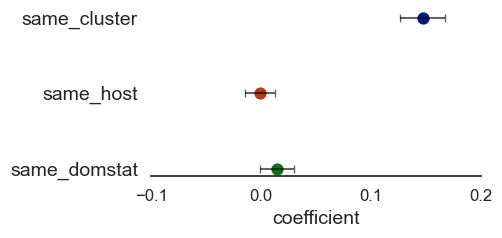

In [64]:
import seaborn as sns
sns.set_theme(style="white", palette=None)

plot_df = coef_df[coef_df['variable']!='Intercept']
# Draw a nested barplot by species and sex
g = sns.catplot(
    data=plot_df, kind="point",
    x="Coef.", y="variable",
    palette="dark", height=2.5, aspect=2
)


plt.errorbar(
    x=plot_df["Coef."],
    y=plot_df["variable"],
    xerr=[plot_df["Coef."] - plot_df["[0.025"], plot_df["0.975]"] - plot_df["Coef."]],
    fmt="none", color="black", alpha=0.6, capsize=3, linewidth=1.5
)
# plt.xticks([0, .1, .2], fontsize=12)
plt.xticks([-0.1, 0, 0.1, 0.2], fontsize=12)
plt.yticks(fontsize=14)

g.despine(left=True)
g.set_axis_labels("coefficient", "", fontsize=14)

filename=('../../comm-pa/output_plots/linreg_prop-shared-vars.pdf')
plt.savefig(filename, format='pdf', dpi=300)
plt.show()

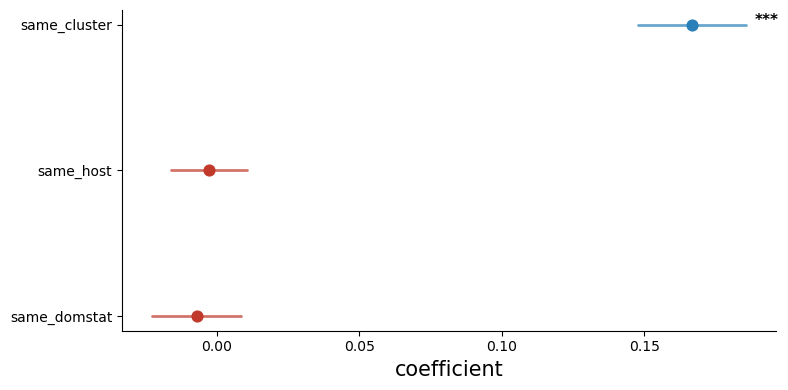

In [134]:
import matplotlib.pyplot as plt
import numpy as np

def plot_coef(summary_df, title="OLS Coefficients", drop_intercept=True, figsize=(8, None)):
    df = summary_df.copy()
    df.index.name = "term"
    df = df.reset_index()
    df.columns = [c.strip() for c in df.columns]

    # summary2() column names
    col_map = {"Coef.": "coef", "[0.025": "ci_lo", "0.975]": "ci_hi", "P>|t|": "pval"}
    df = df.rename(columns=col_map)

    if drop_intercept:
        df = df[df["term"] != "Intercept"]

    df = df.sort_values("coef").reset_index(drop=True)

    def stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    df["stars"] = df["pval"].apply(stars)

    n = len(df)
    h = figsize[1] or max(4, n)
    fig, ax = plt.subplots(figsize=(figsize[0], h))

    colors = ["#c0392b" if c < 0 else "#2980b9" for c in df["coef"]]

    for i, row in df.iterrows():
        color = "#c0392b" if row["coef"] < 0 else "#2980b9"
        # CI line
        ax.plot([row["ci_lo"], row["ci_hi"]], [row["term"], row["term"]],
                color=color, linewidth=2, alpha=0.7, solid_capstyle="round")
        # Mean point
        ax.scatter(row["coef"], row["term"], color=color, s=60, zorder=5)
        # Stars
        if row["stars"]:
            x = row["ci_hi"] if row["coef"] >= 0 else row["ci_lo"]
            ha = "left" if row["coef"] >= 0 else "right"
            ax.text(x + (0.003 if row["coef"] >= 0 else -0.003), row["term"],
                    row["stars"], va="baseline", ha=ha, fontsize=11, fontweight="bold", color="black")

    # ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("coefficient", fontsize=15)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_coef(model.summary2().tables[1])

In [105]:
print(model.params)
print(model.conf_int())

Intercept              0.011778
same_cluster[T.Yes]    0.166818
same_host[T.Yes]      -0.002629
same_domstat[T.Yes]   -0.007033
dtype: float64
                            0         1
Intercept            0.000543  0.023013
same_cluster[T.Yes]  0.147892  0.185745
same_host[T.Yes]    -0.015839  0.010582
same_domstat[T.Yes] -0.022730  0.008664


In [43]:
merged['sample_species'].value_counts()

sample_species
chicken            51
duck               40
chukar             38
khaki campbell     30
guniea             14
chicken broiler    13
goose               3
Name: count, dtype: int64

In [49]:
merged['order'] ='unknown'

merged

,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status,sample_species,date_collected,outbreak,order
0,Lys339Thr,c_lbm5,PB2_339,nonsynonymous,LBM,chicken,2025-03-10,3,unknown
1,Lys339Thr,c_lbm8,PB2_339,nonsynonymous,LBM,chicken,2025-03-10,3,unknown
2,Lys353Lys,ckr_com1,PB2_353,synonymous,commercial,chukar,2025-07-01,4,unknown
3,Lys353Lys,ckr_com3,PB2_353,synonymous,commercial,chukar,2025-07-01,4,unknown
4,Glu358Glu,ckr_com1,PB2_358,synonymous,commercial,chukar,2025-07-01,4,unknown
...,...,...,...,...,...,...,...,...,...
184,Ile393Met,c_lbm5,NA_393,nonsynonymous,LBM,chicken,2025-03-10,3,unknown
185,Met393Ile,c_lbm7,NA_393,nonsynonymous,LBM,chicken,2025-03-10,3,unknown
186,Ile393Met,d_lbm3,NA_393,nonsynonymous,LBM,duck,2025-03-10,3,unknown
187,Ile418Met,c_lbm1,NA_418,nonsynonymous,LBM,chicken,2025-02-20,2,unknown


In [50]:
# List of species to assign 'wild'
merged['order'] =='unknown'

# List of species to assign 'domestic'
gall = ['chicken', 'chukar', 'guniea', 'chicken broiler']
anser = ['duck', 'khaki campbell', 'goose']

# Assign 'domestic' if dom_stat is unknown and species is in domestic list
merged.loc[(merged['order'] == 'unknown') & (merged['sample_species'].isin(gall)), 'order'] = 'galliformes'
merged.loc[(merged['order'] == 'unknown') & (merged['sample_species'].isin(anser)), 'order'] = 'anseriformes'
merged

,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status,sample_species,date_collected,outbreak,order
0,Lys339Thr,c_lbm5,PB2_339,nonsynonymous,LBM,chicken,2025-03-10,3,galliformes
1,Lys339Thr,c_lbm8,PB2_339,nonsynonymous,LBM,chicken,2025-03-10,3,galliformes
2,Lys353Lys,ckr_com1,PB2_353,synonymous,commercial,chukar,2025-07-01,4,galliformes
3,Lys353Lys,ckr_com3,PB2_353,synonymous,commercial,chukar,2025-07-01,4,galliformes
4,Glu358Glu,ckr_com1,PB2_358,synonymous,commercial,chukar,2025-07-01,4,galliformes
...,...,...,...,...,...,...,...,...,...
184,Ile393Met,c_lbm5,NA_393,nonsynonymous,LBM,chicken,2025-03-10,3,galliformes
185,Met393Ile,c_lbm7,NA_393,nonsynonymous,LBM,chicken,2025-03-10,3,galliformes
186,Ile393Met,d_lbm3,NA_393,nonsynonymous,LBM,duck,2025-03-10,3,anseriformes
187,Ile418Met,c_lbm1,NA_418,nonsynonymous,LBM,chicken,2025-02-20,2,galliformes


In [59]:
merged.tail(25)

,coding_region_change,sample_ID,gene_pos,syn_non,domestic_status,sample_species,date_collected,outbreak,order
164,Leu551Leu,c_lbm10,HA_551,synonymous,LBM,chicken,2025-03-11,3,galliformes
165,Leu551Leu,c_lbm11,HA_551,synonymous,LBM,chicken,2025-03-11,3,galliformes
166,Leu551Leu,d_lbm4,HA_551,synonymous,LBM,duck,2025-03-11,3,anseriformes
167,Ile29Met,c_lbm2,NA_29,nonsynonymous,LBM,chicken,2025-02-20,2,galliformes
168,Ile29Met,gn_lbm1,NA_29,nonsynonymous,LBM,guniea,2025-02-20,2,galliformes
169,Asn71Asp,c_lbm5,NA_71,nonsynonymous,LBM,chicken,2025-03-10,3,galliformes
170,Asn71Ser,c_lbm7,NA_71,nonsynonymous,LBM,chicken,2025-03-10,3,galliformes
171,Leu134Ile,d_lbm2,NA_134,nonsynonymous,LBM,duck,2025-02-20,2,anseriformes
172,Leu134Ile,gn_lbm1,NA_134,nonsynonymous,LBM,guniea,2025-02-20,2,galliformes
173,Ser160Ser,c_lbm5,NA_160,synonymous,LBM,chicken,2025-03-10,3,galliformes


In [51]:
variant_clusters_duckchick = (
    merged.groupby("gene_pos")["order"]
      .apply(lambda x: sorted(x.unique()))
      .reset_index(name="clusters_in")
)
variant_clusters_duckchick

,gene_pos,clusters_in
0,HA_145,"[anseriformes, galliformes]"
1,HA_153,"[anseriformes, galliformes]"
2,HA_351,[galliformes]
3,HA_472,[galliformes]
4,HA_538,[galliformes]
5,HA_551,"[anseriformes, galliformes]"
6,HA_96,[anseriformes]
7,M2_33,"[anseriformes, galliformes]"
8,NA_134,"[anseriformes, galliformes]"
9,NA_160,"[anseriformes, galliformes]"


In [52]:
variant_clusters_domstat = (
    merged.groupby("gene_pos")["domestic_status"]
      .apply(lambda x: sorted(x.unique()))
      .reset_index(name="clusters_in")
)
variant_clusters_domstat

,gene_pos,clusters_in
0,HA_145,[LBM]
1,HA_153,"[LBM, commercial]"
2,HA_351,"[LBM, commercial]"
3,HA_472,[commercial]
4,HA_538,[commercial]
5,HA_551,[LBM]
6,HA_96,"[LBM, commercial]"
7,M2_33,[commercial]
8,NA_134,[LBM]
9,NA_160,"[LBM, commercial]"


In [42]:
variant_clusters = (
    merged.groupby("gene_pos")["outbreak"]
      .apply(lambda x: sorted(x.unique()))
      .reset_index(name="clusters_in")
)
variant_clusters

,gene_pos,clusters_in
0,HA_145,[3]
1,HA_153,"[1, 2]"
2,HA_351,"[1, 3]"
3,HA_472,[1]
4,HA_538,[4]
5,HA_551,[3]
6,HA_96,"[3, 4]"
7,M2_33,[1]
8,NA_134,[2]
9,NA_160,"[1, 3]"


In [55]:
merge1 = pd.merge(variant_clusters, variant_clusters_domstat, on='gene_pos', how='left')
merge1

,gene_pos,clusters_in_x,clusters_in_y
0,HA_145,[3],[LBM]
1,HA_153,"[1, 2]","[LBM, commercial]"
2,HA_351,"[1, 3]","[LBM, commercial]"
3,HA_472,[1],[commercial]
4,HA_538,[4],[commercial]
5,HA_551,[3],[LBM]
6,HA_96,"[3, 4]","[LBM, commercial]"
7,M2_33,[1],[commercial]
8,NA_134,[2],[LBM]
9,NA_160,"[1, 3]","[LBM, commercial]"


In [56]:
merge2 = pd.merge(merge1, variant_clusters_duckchick, on='gene_pos', how='left')
merge2

,gene_pos,clusters_in_x,clusters_in_y,clusters_in
0,HA_145,[3],[LBM],"[anseriformes, galliformes]"
1,HA_153,"[1, 2]","[LBM, commercial]","[anseriformes, galliformes]"
2,HA_351,"[1, 3]","[LBM, commercial]",[galliformes]
3,HA_472,[1],[commercial],[galliformes]
4,HA_538,[4],[commercial],[galliformes]
5,HA_551,[3],[LBM],"[anseriformes, galliformes]"
6,HA_96,"[3, 4]","[LBM, commercial]",[anseriformes]
7,M2_33,[1],[commercial],"[anseriformes, galliformes]"
8,NA_134,[2],[LBM],"[anseriformes, galliformes]"
9,NA_160,"[1, 3]","[LBM, commercial]","[anseriformes, galliformes]"


In [63]:


variant_summary = (
    merged.groupby("gene_pos")
      .agg(
          # clusters_in=("cluster", lambda x: sorted(x.unique())),
          # n_clusters=("cluster", "nunique"),
          n_occurrences=("gene_pos", "count")
      )
      .reset_index()
)
variant_summary

,gene_pos,n_occurrences
0,HA_145,4
1,HA_153,3
2,HA_351,2
3,HA_472,2
4,HA_538,2
5,HA_551,3
6,HA_96,4
7,M2_33,2
8,NA_134,2
9,NA_160,2


In [64]:
merge3 = pd.merge(merge2, variant_summary, on='gene_pos', how='left')
merge3

,gene_pos,clusters_in_x,clusters_in_y,clusters_in,n_occurrences
0,HA_145,[3],[LBM],"[anseriformes, galliformes]",4
1,HA_153,"[1, 2]","[LBM, commercial]","[anseriformes, galliformes]",3
2,HA_351,"[1, 3]","[LBM, commercial]",[galliformes],2
3,HA_472,[1],[commercial],[galliformes],2
4,HA_538,[4],[commercial],[galliformes],2
5,HA_551,[3],[LBM],"[anseriformes, galliformes]",3
6,HA_96,"[3, 4]","[LBM, commercial]",[anseriformes],4
7,M2_33,[1],[commercial],"[anseriformes, galliformes]",2
8,NA_134,[2],[LBM],"[anseriformes, galliformes]",2
9,NA_160,"[1, 3]","[LBM, commercial]","[anseriformes, galliformes]",2
